# Bias-Variance Decomposition in Practice

Проект исследует, как сложность модели, размер обучающей выборки и шум влияют на bias, variance и итоговую квадратичную ошибку регрессии. Синтетическая часть позволяет вычислить компоненты разложения напрямую. Реальные данные используются для проверки устойчивости фиксированных конфигураций моделей.

## Математическая постановка

Для squared loss и случайной обучающей выборки $D$ выполняется

$$
\mathbb{E}_{D,\varepsilon}\left[(Y-\hat f_D(x))^2\right]
=
\left(\mathbb{E}_D[\hat f_D(x)]-f(x)\right)^2
+
\mathbb{V}_D[\hat f_D(x)]
+
\sigma^2.
$$

Monte Carlo оценка использует одну evaluation grid для всех повторений. Точки этой сетки не участвуют в обучении. Train data, model initialization и test noise получают независимые seed schedules.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

from bias_variance_project.core import (
    bias_variance_decomposition,
    generate_synthetic,
    generate_training_sets,
)
from bias_variance_project.experiments import (
    DATA_SEED,
    MODEL_SEED,
    TEST_NOISE_SEED,
)

ROOT = Path.cwd()
TABLES = ROOT / "reports" / "tables"
FIGURES = ROOT / "reports" / "figures"


def show_figure(name, figsize=(12, 6)):
    image = plt.imread(FIGURES / name)
    plt.figure(figsize=figsize)
    plt.imshow(image)
    plt.axis("off")
    plt.show()

## Синтетические данные

Данные генерируются по схеме $X \sim U[-3, 3]$ и $Y = \sin(2X) + 0.2X^2 + \varepsilon$. Нелинейная функция содержит области разной кривизны, поэтому на ней видны как underfitting простых моделей, так и рост variance гибких моделей.

sample shape = (160, 1), target shape = (160,)


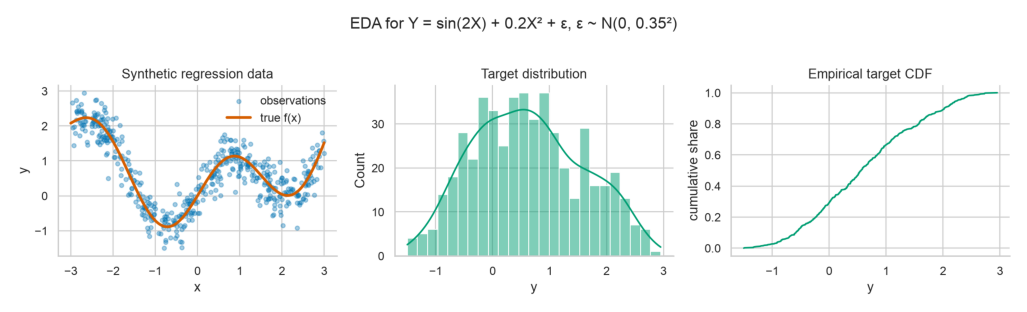

In [2]:
x_sample, y_sample = generate_synthetic(160, sigma=0.35, seed=DATA_SEED)
print(f"sample shape = {x_sample.shape}, target shape = {y_sample.shape}")
show_figure("synthetic_eda.png", figsize=(13, 4))

## Прямая проверка разложения

Следующая ячейка действительно выполняет Monte Carlo эксперимент. Polynomial Ridge степени 7 обучается на 80 независимых выборках. Для каждого повтора используются отдельные seeds данных, модели и тестового шума.

In [3]:
training_sets = generate_training_sets(
    n_repeats=80,
    n_train=160,
    sigma=0.35,
    data_seed=DATA_SEED,
)
x_eval = np.linspace(-3, 3, 240).reshape(-1, 1)

result, predictions = bias_variance_decomposition(
    lambda seed: make_pipeline(
        PolynomialFeatures(degree=7, include_bias=False),
        StandardScaler(),
        Ridge(alpha=1e-3),
    ),
    training_sets=training_sets,
    x_eval=x_eval,
    sigma=0.35,
    model_seed=MODEL_SEED,
    test_noise_seed=TEST_NOISE_SEED,
)

display(pd.Series(result).to_frame("estimate").round(5))
print(f"prediction matrix shape = {predictions.shape}")

,estimate
bias2,0.00091
variance,0.00722
noise,0.12250
expected_mse,0.13064
empirical_mse,0.12856
decomposition_gap,-0.00208


prediction matrix shape = (80, 240)


`decomposition_gap` является конечной Monte Carlo погрешностью между empirical MSE и суммой оценённых компонентов. Это не дополнительный компонент ошибки.

## Сложность моделей

Полный запуск сравнивает Polynomial Ridge, Decision Tree, KNN, Random Forest и MLP на одинаковых последовательностях train samples. Для Random Forest и MLP model seed меняется независимо от data seed. Поэтому измеряемая variance включает изменение данных и stochasticity алгоритма.

,model,complexity_label,complexity,bias2,variance,noise,expected_mse,empirical_mse,decomposition_gap
0,Polynomial Ridge,degree,7,0.0009,0.0071,0.1225,0.1305,0.1273,-0.0032
1,KNN,n_neighbors,12,0.0058,0.0145,0.1225,0.1428,0.1383,-0.0045
2,MLP,hidden_width,64,0.0100,0.0122,0.1225,0.1446,0.1400,-0.0046
3,Random Forest,max_depth,4,0.0083,0.0251,0.1225,0.1558,0.1537,-0.0022
4,Decision Tree,max_depth,5,0.0023,0.0553,0.1225,0.1802,0.1796,-0.0006


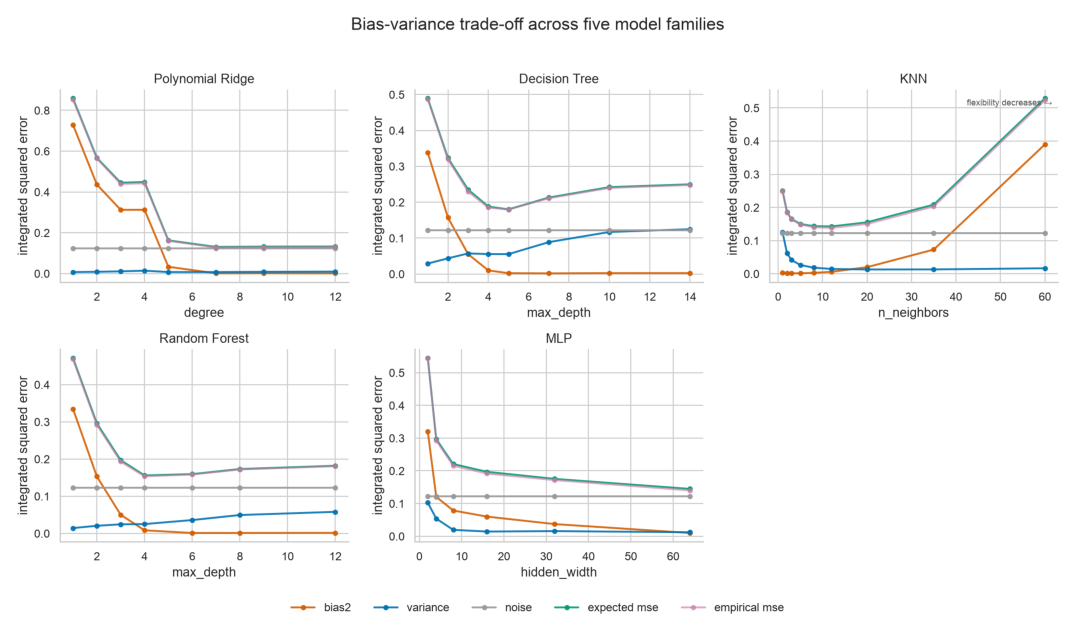

In [4]:
complexity = pd.read_csv(TABLES / "complexity_results.csv")
best = pd.read_csv(TABLES / "best_complexity_summary.csv")
display(best.round(4))
show_figure("complexity_tradeoff.png", figsize=(14, 8))

Polynomial Ridge степени 7 показывает наименьший expected MSE около 0.130. KNN и MLP дают близкие значения около 0.143 и 0.145. У дерева после глубины 5 снижение bias сопровождается более быстрым ростом variance. Random Forest сглаживает этот рост за счёт усреднения деревьев.

## Размер выборки и шум

Decision Tree глубины 6 используется как чувствительная к данным модель. Увеличение train size должно уменьшать variance. Рост $\sigma$ увеличивает noise напрямую и одновременно усложняет восстановление функции по конечной выборке.

,study,value,value_label,bias2,variance,noise,expected_mse,empirical_mse,decomposition_gap
0,sample_size,40.00,n_train,0.0048,0.1304,0.1225,0.2577,0.2525,-0.0052
1,sample_size,80.00,n_train,0.0035,0.0952,0.1225,0.2213,0.2126,-0.0087
2,sample_size,160.00,n_train,0.0019,0.0718,0.1225,0.1962,0.1886,-0.0076
3,sample_size,320.00,n_train,0.0016,0.0488,0.1225,0.1729,0.1690,-0.0039
4,noise,0.10,sigma,0.0013,0.0101,0.0100,0.0214,0.0205,-0.0009
5,noise,0.20,sigma,0.0012,0.0261,0.0400,0.0673,0.0647,-0.0026
6,noise,0.35,sigma,0.0019,0.0718,0.1225,0.1962,0.1886,-0.0076
7,noise,0.60,sigma,0.0047,0.2029,0.3600,0.5676,0.5422,-0.0254
8,noise,0.90,sigma,0.0120,0.4507,0.8100,1.2727,1.2194,-0.0533


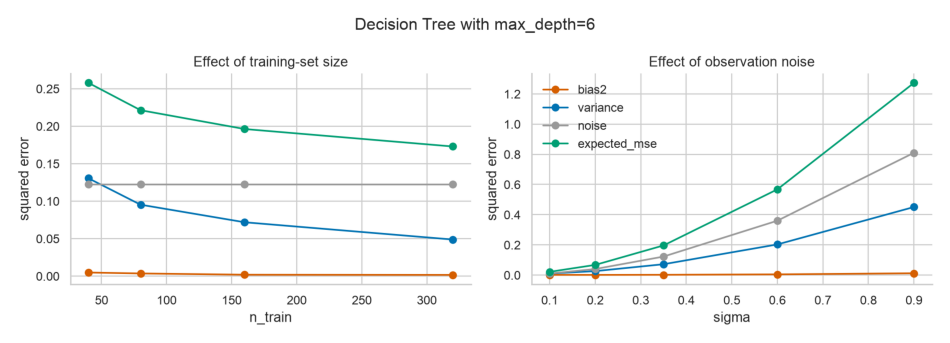

In [5]:
train_size_noise = pd.read_csv(TABLES / "train_size_noise_results.csv")
display(train_size_noise.round(4))
show_figure("train_size_noise_effects.png", figsize=(12, 5))

При росте обучающей выборки с 40 до 320 объектов variance уменьшается примерно с 0.130 до 0.049. При $\sigma=0.9$ компонент noise равен 0.81 и становится основной частью expected MSE.

## Подбор классических моделей и обучение MLP

Grid search использует одинаковые пять folds для всех классических моделей. PolynomialFeatures и StandardScaler находятся внутри sklearn Pipeline. Отдельный MLP эксперимент выполняет по одной итерации `fit` с `warm_start=True`, поэтому каждая строка истории соответствует одной дополнительной эпохе Adam. Ожидаемый `ConvergenceWarning` подавляется только внутри этого цикла.

,model,cv_folds,best_cv_rmse,best_params
0,Polynomial Ridge,5,0.344444,"{'polynomialfeatures__degree': 7, 'ridge__alph..."
1,KNN,5,0.352054,{'kneighborsregressor__n_neighbors': 20}
2,Random Forest,5,0.367186,"{'max_depth': 7, 'min_samples_leaf': 6}"
3,Decision Tree,5,0.377743,"{'max_depth': 6, 'min_samples_leaf': 6}"


,best validation epoch
epoch,216.0000
train_loss,0.0825
train_rmse,0.4048
val_rmse,0.4696


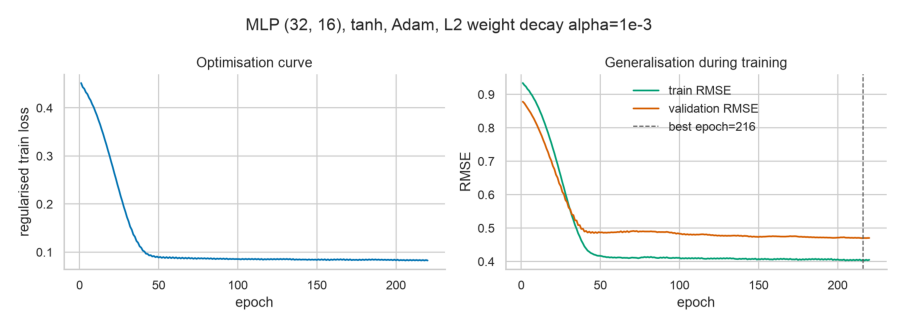

In [6]:
tuning = pd.read_csv(TABLES / "classical_tuning.csv")
history = pd.read_csv(TABLES / "mlp_training_history.csv")
display(tuning)
best_epoch = history.loc[history["val_rmse"].idxmin()]
display(best_epoch.to_frame("best validation epoch").round(4))
show_figure("mlp_training_history.png", figsize=(12, 4))

## Реальные данные

Используются исходные признаки Diabetes и Linnerud. Дополнительные engineered features не добавляются, поскольку они не нужны для исследования bias-variance и особенно слабо обоснованы для Linnerud. Все результаты ниже относятся к фиксированным конфигурациям моделей, а не к оптимальным представителям каждого семейства.

,dataset,rows,features,missing_values,target_mean,target_std,target_iqr_outliers
0,Diabetes,442,10,0,152.133,77.093,0
1,Linnerud-Weight,20,3,0,178.600,24.691,1


,dataset,model,rmse_mean,rmse_std,r2_mean
0,Diabetes,Ridge,54.857,3.046,0.486
1,Diabetes,MLP,55.982,4.321,0.464
2,Diabetes,Gradient Boosting,56.533,3.163,0.455
3,Diabetes,Random Forest,57.349,3.916,0.438
4,Diabetes,Decision Tree,64.303,3.789,0.293
5,Diabetes,Dummy,77.159,3.155,-0.016
6,Linnerud-Weight,Ridge,22.788,10.018,-0.597
7,Linnerud-Weight,Decision Tree,22.967,8.666,-1.044
8,Linnerud-Weight,Random Forest,23.247,8.096,-0.907
9,Linnerud-Weight,Dummy,23.779,9.063,-0.785


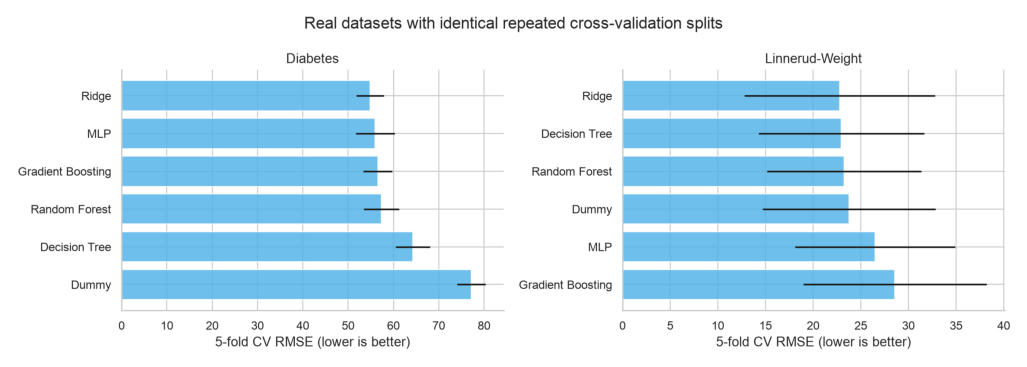

In [7]:
overview = pd.read_csv(TABLES / "real_data_overview.csv")
real_summary = pd.read_csv(TABLES / "real_model_summary.csv")
display(overview.round(3))
display(real_summary.round(3))
show_figure("real_model_comparison.png", figsize=(13, 5))

На Diabetes Ridge показывает наименьший средний RMSE около 54.86, но несколько нелинейных конфигураций находятся рядом. На Linnerud всего 20 наблюдений, стандартное отклонение RMSE велико, а средний $R^2$ отрицателен у всех конфигураций. Такой результат не позволяет уверенно ранжировать семейства моделей.

## Paired bootstrap на реальных данных

Для каждого датасета bootstrap indices генерируются заранее и повторно используются всеми моделями. Истинная функция регрессии неизвестна, поэтому таблица не является классическим разложением. `bootstrap_variance` измеряет чувствительность к перевыборке, а `proxy_bias2` вычисляется относительно Gradient Boosting reference model.

,dataset,model,proxy_bias2,bootstrap_variance,residual_noise_proxy,test_mse,n_bootstrap
0,Diabetes,Dummy,2733.560,18.427,3026.055,5485.225,60
1,Diabetes,Ridge,446.707,83.883,3026.055,2799.237,60
2,Diabetes,Decision Tree,194.052,1153.342,3026.055,3332.070,60
3,Diabetes,Random Forest,141.468,299.697,3026.055,3175.684,60
4,Diabetes,Gradient Boosting,103.204,198.421,3026.055,2940.660,60
5,Diabetes,MLP,435.928,421.611,3026.055,2748.750,60
6,Linnerud-Weight,Dummy,94.830,24.782,1699.302,1158.155,60
7,Linnerud-Weight,Ridge,163.696,40.537,1699.302,896.674,60
8,Linnerud-Weight,Decision Tree,160.510,116.729,1699.302,922.068,60
9,Linnerud-Weight,Random Forest,131.820,66.631,1699.302,975.248,60


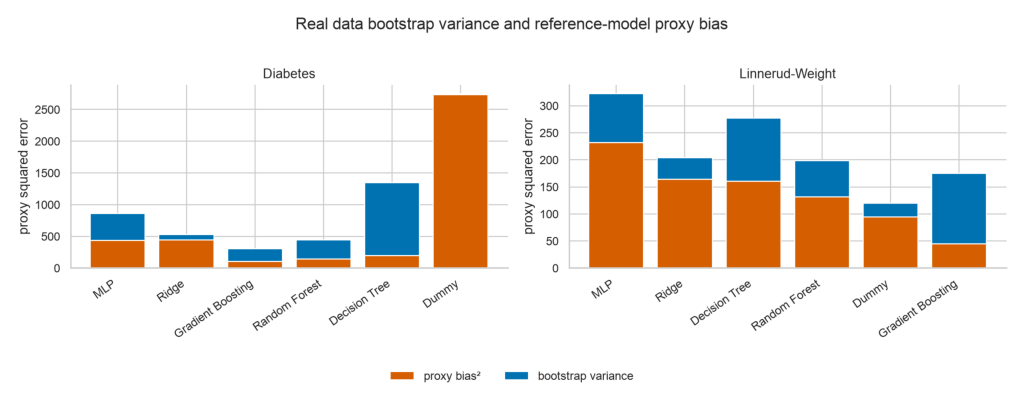

In [8]:
proxy = pd.read_csv(TABLES / "real_proxy_decomposition.csv")
display(proxy.round(3))
show_figure("real_proxy_decomposition.png", figsize=(13, 5))

На Diabetes дерево имеет заметно более высокую bootstrap variance, чем Ridge и ансамбли. На Linnerud все proxy оценки нестабильны из-за малого размера train split. Их следует использовать как диагностику, а не как точную оценку Bias².

## Ограничения

- Synthetic decomposition является Monte Carlo оценкой с конечным числом повторений
- Variance Random Forest и MLP включает stochasticity алгоритма
- На реальных данных неизвестны $f(x)$ и истинный noise
- Proxy bias зависит от выбранной reference model
- Real-data выводы относятся только к заданным конфигурациям
- Linnerud слишком мал для устойчивого ранжирования моделей

## Выводы

Эксперимент напрямую воспроизводит bias-variance trade-off для пяти семейств моделей. Гибкость снижает bias лишь до точки, после которой variance начинает увеличивать общую ошибку. Размер обучающей выборки уменьшает variance, а наблюдаемый шум задаёт неустранимую часть ошибки. На реальных данных классическое разложение недоступно, поэтому CV и paired bootstrap дают более осторожную картину стабильности фиксированных моделей.